# Turning Raw E-Commerce Tables into an Analytical System

*Data integration, cleaning, and design decisions.* 

## 1. Introduction
E-commerce has become an ordinary part of daily life, but the systems behind it are anything but simple. The data generated by these platforms reflects a combination of customer behavior, operational constraints, and downstream outcomes that are rarely visible all at once.

This notebook focuses on preparing and integrating a collection of interrelated e-commerce datasets provided by Olist, a Brazilian online marketplace that connects small and medium-sized sellers to customers through major platforms. The data spans customers, orders, products, sellers, logistics events, reviews, and geolocation, capturing multiple perspectives of the same system.

This dataset was selected not only for its relational complexity, but because the domain itself is inherently interesting. E-commerce platforms generate large volumes of interconnected behavioral and operational data, making them well-suited for exploratory analysis. Rather than beginning with a predefined modeling target, this project began with a broader goal: to explore the structure of the data, understand how the different components of the marketplace interacted, and identify meaningful patterns as they emerged through analysis.

## 2. Libraries and Environment Setup
### 2.1 Libraries
The following libraries are used for data loading, inspection, cleaning, and integration throughout this notebook.

In [1]:
# File handling
import os
import sys

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import unicodedata

# Validation checks
import warnings
warnings.simplefilter("always")

### 2.2 Environment Configuration
The following configurations are used to improve notebook readability, consistency, and validation during analysis.

In [2]:
sys.path.append("..")
from config import RAW_DATA, REFERENCE_DATA, PROCESSED_DATA

### 2.3 Display Settings
The following display settings are configured to support data inspection, validation, and review throughout the data wrangling process.

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

## 3. Read Files and Datasets Overview
The analysis begins by loading the individual datasets that collectively describe different components of the e-commerce system.

Each dataset captures a different aspect of the marketplace, and understanding their roles upfront helps guide subsequent cleaning, validation, and integration decisions.

In [4]:
# Load datasets
customers = pd.read_csv(os.path.join(RAW_DATA, 'olist_customers_dataset.csv'))
geolocation = pd.read_csv(os.path.join(RAW_DATA, 'olist_geolocation_dataset.csv'))
order_items = pd.read_csv(os.path.join(RAW_DATA, 'olist_order_items_dataset.csv'))
order_payments = pd.read_csv(os.path.join(RAW_DATA, 'olist_order_payments_dataset.csv'))
order_reviews = pd.read_csv(os.path.join(RAW_DATA, 'olist_order_reviews_dataset.csv'))
orders = pd.read_csv(os.path.join(RAW_DATA, 'olist_orders_dataset.csv'))
products = pd.read_csv(os.path.join(RAW_DATA, 'olist_products_dataset.csv'))
sellers = pd.read_csv(os.path.join(RAW_DATA, 'olist_sellers_dataset.csv'))

# Product category translation
product_category_name_translation = pd.read_csv(os.path.join(REFERENCE_DATA, 'product_category_name_translation.csv'))

**Dataset Descriptions** 
* **Customers:** Customer identifiers and approximate geographic information.
* **Geolocation:** Reference latitude and longitude data for Brazilian postal codes.
* **Orders:** Order lifecycle events and status timestamps.
* **Order Items:** Product-level details for each order, including price and freight.
* **Order Payments:** Payment method and transaction information.
* **Order Reviews:** Customer review scores and feedback.
* **Products:** Product metadata and category information.
* **Sellers:** Seller identifiers and location data.
* **Product Category Name Translation:** Mapping between Portuguese and English product category names.

## 4. Initial Dataset Diagnostics
Before integrating the datasets, an initial diagnostic review was conducted to establish a broad understanding of their structure and overall completeness.

Because the workflow involves multiple interconnected datasets, a dictionary-based structure and reusable helper functions are used throughout this section to streamline repetitive validation tasks and maintain consistency across tables.

The analysis begins with a dataset-level overview to examine dataset size and the presence of missing values across tables before moving to a more detailed, column-level inspection of null value patterns and data types within individual datasets.

### 4.1 Dataset-Level Overview
The analysis begins with a dataset-level overview to establish a coarse understanding of the data.

At this stage, the goal is to identify broad structural characteristics, such as dataset size and the presence of missing values, before deciding whether deeper inspection is warranted.

In [5]:
all_dfs_dict = {
    'sellers':sellers, 
    'orders':orders, 
    'order_items':order_items, 
    'customers': customers, 
    'geolocation':geolocation, 
    'order_payments':order_payments, 
    'order_reviews':order_reviews, 
    'products':products
    }

In [6]:
def create_null_summary(dataset_dict):
    """
    Create a dataset-level overview of size and missing values.
    """
    null_list = []
    for name, df in dataset_dict.items():
        n_rows = df.shape[0]
        n_cols = df.shape[1]
        null_sum = df.isna().any(axis=1).sum()
        # get list of column names with null values
        null_columns = df.columns[df.isnull().any()].tolist()
        # get number of columns with null values 
        n_null_columns = len(null_columns)
        # if no null columns, return an empty string
        null_columns_str = ', '.join(null_columns) if null_columns else ""
        null_list.append({
                        "dataframe":name,
                        "n_rows":n_rows,
                        "n_cols": n_cols,
                        "rows_with_nulls":null_sum,
                        "pct_rows_with_nulls": round((null_sum / n_rows * 100) if n_rows else 0, 3),
                        "columns_with_nulls":n_null_columns,
                        "null_columns_names":null_columns_str})
    return pd.DataFrame(null_list)


In [7]:
null_df = create_null_summary(all_dfs_dict).sort_values(
    by="pct_rows_with_nulls",
    ascending=False
)
null_df

,dataframe,n_rows,n_cols,rows_with_nulls,pct_rows_with_nulls,columns_with_nulls,null_columns_names
6,order_reviews,99224,7,89385,90.084,2,"review_comment_title, review_comment_message"
1,orders,99441,8,2980,2.997,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
7,products,32951,9,611,1.854,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
0,sellers,3095,4,0,0.000,0,
2,order_items,112650,7,0,0.000,0,
3,customers,99441,5,0,0.000,0,
4,geolocation,1000163,5,0,0.000,0,
5,order_payments,103886,5,0,0.000,0,


**Observations from the Dataset-Level Overview**
* The `geolocation` dataset contains substantially more records than the `customers` dataset, indicating that postal code references are reused across many entities rather than being unique to individual customers.
* The `sellers` and `order_items` tables suggest that multiple products can be associated with a single seller.
* Most orders have an associated review record; however, a large proportion of reviews are missing titles and message text, indicating partial rather than complete feedback.
* Several orders contain multiple items, reflecting one-to-many relationships between orders and products.
* Some orders are missing lifecycle timestamps or delivery-related fields, which likely correspond to orders that were canceled, unavailable, or still in progress.
* Certain products lack complete descriptive information, suggesting variability in how sellers populate product metadata.

The dataset-level overview provides a broad sense of scale and overall completeness across tables. While this view is sufficient to confirm that missing values are present, it does not reveal how those values are distributed across individual columns. Questions raised at this stage motivated a closer, column-level examination of the data.

### 4.2 Column-Level Data Profile
The dataset-level overview indicated that missing values were present across several tables, but it did not reveal how those gaps were distributed within individual datasets.

To better understand which fields are affected and whether missing values are concentrated in specific columns or spread more evenly, the analysis now turns to a column-level data profile.

In [8]:
def summarize_columns(dataset_dict):
    """
    Generate a column-level summary across multiple datasets.
    """
    summary_list = []
    for name, df in dataset_dict.items():
        total_rows = len(df)
        for col in df.columns:
            null_count = df[col].isnull().sum()
            dtype = df[col].dtype
            summary_list.append({
                "dataframe": name,
                "column": col,
                "dtype": dtype,
                "num_nulls": null_count,
                "percent_null":round(null_count / total_rows * 100, 2)})
    return pd.DataFrame(summary_list)

column_summary = summarize_columns(all_dfs_dict)
column_summary

,dataframe,column,dtype,num_nulls,percent_null
0,sellers,seller_id,str,0,0.00
1,sellers,seller_zip_code_prefix,int64,0,0.00
2,sellers,seller_city,str,0,0.00
3,sellers,seller_state,str,0,0.00
4,orders,order_id,str,0,0.00
5,orders,customer_id,str,0,0.00
6,orders,order_status,str,0,0.00
7,orders,order_purchase_timestamp,str,0,0.00
8,orders,order_approved_at,str,160,0.16
9,orders,order_delivered_carrier_date,str,1783,1.79


**Observations from the Column-Level Data Profile**
* Product-related tables contain physical, textual, and category-level attributes with relatively high completeness, providing strong coverage for downstream analysis.
* Several fields across datasets are currently stored as generic `object` types and will require conversion to appropriate date or time formats to support temporal analysis.
* Multiple datasets contain overlapping identifier fields linking `customers`, `orders`, `products`, and `sellers`, enabling integration across different levels of marketplace activity.
* For the majority of columns across datasets, missing values are minimal, with most fields exhibiting less than 3% null values and many being fully populated. This indicates strong overall data completeness and no immediate data quality concerns.
* Review text fields in `order_reviews` are notably sparse: only a small proportion of reviews include written content, with roughly 12% containing a title and about 40% containing a message.
* Despite limited review text coverage, core review fields such as review score and review creation timestamps are fully populated, preserving important indicators of customer feedback and order experience.
* Product category names and review text fields are stored in Portuguese. A separate translation dataset, `product_category_name_translation`, is available for product category names, enabling alignment for analysis, while review text fields are deprioritized given both language constraints and their limited coverage.

### 4.3 Initial Dataset Diagnostics Summary

Initial diagnostics revealed that the collection of datasets is highly relational, with different tables operating at distinct levels of granularity, including customer-level, order-level, item-level, review-level, and geolocation-level records. This distinction is important because joins performed without careful consideration of granularity could unintentionally duplicate observations or distort downstream analysis.

Overall, the datasets exhibit strong completeness, with missing values concentrated primarily in optional descriptive fields, review text content, and certain order lifecycle timestamps. Most core transactional and identifier fields are well populated, supporting reliable integration across tables.

The diagnostics process also highlighted several important preparation steps for later stages of the workflow, including timestamp conversion, translation of Portuguese product categories using `product_category_name_translation`, and validation of relationships across datasets before constructing a unified analytical view.

## 5. Data Cleaning and Standardization

### 5.1 Text Normalization
Several datasets contain textual fields that are intended to represent the same entities but originate from different sources, including geographic location names and product category labels.

Prior to integrating these datasets, textual fields are normalized to reduce the risk of mismatches caused by differences in capitalization, accent usage, formatting, and inconsistent naming conventions. Additional standardization steps are also applied to improve consistency across identifiers and column names used throughout the workflow.

These preprocessing steps help ensure that text-based joins are reliable and not affected by superficial variation.

In [9]:
def normalize_text(name):
    """
    Standardize text by lowercasing, removing accents and special characters,
    and normalizing whitespace. Preserves missing values.
    """
    if pd.isna(name):
        return name
    name = str(name).lower().strip()
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('ascii')
    name = re.sub(r'[^a-z0-9\s]', ' ', name)
    name = re.sub(r'\s+', ' ', name)
    return name.strip()

In [10]:
# apply normalization
geolocation['city_clean_name'] = geolocation['geolocation_city'].map(normalize_text)
customers['city_clean_name'] = customers['customer_city'].map(normalize_text)
sellers['city_clean_name']   = sellers['seller_city'].map(normalize_text)

geolocation['state_clean_name'] = geolocation['geolocation_state'].map(normalize_text)
customers['state_clean_name'] = customers['customer_state'].map(normalize_text)
sellers['state_clean_name'] = sellers['seller_state'].map(normalize_text)

# normalize product category names prior to translation merge
products['product_category_name_clean'] = products['product_category_name'].map(normalize_text)
product_category_name_translation['product_category_name_clean'] = product_category_name_translation['product_category_name'].map(normalize_text)

In [11]:
# Correct misspelled product metadata column names
products.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length"}, 
                        inplace = True)

In [12]:
products.head()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_clean
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,esporte lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,utilidades domesticas


In [13]:
# Add leading zeros to Zip Codes
customers['customer_zip_code_prefix'] = (
    customers['customer_zip_code_prefix']
    .astype("string")
    .str.zfill(5)
)

sellers['seller_zip_code_prefix'] = (
    sellers['seller_zip_code_prefix']
    .astype("string")
    .str.zfill(5)
)

geolocation['geolocation_zip_code_prefix'] = (
    geolocation['geolocation_zip_code_prefix']
    .astype("string")
    .str.zfill(5)
)

**Observations from Text Normalization**
* Geographic location fields across `customers`, `sellers`, and `geolocation` contained inconsistencies in capitalization, accent usage, and formatting that could interfere with reliable text-based matching.
* Product category labels required normalization prior to translation merging to reduce the likelihood of mismatched categories caused by formatting variation.
* Several identifier and metadata fields required standardization, including zero-padding ZIP code prefixes and correcting misspelled product metadata column names.
* Standardizing textual and identifier fields early in the workflow helps reduce integration risk and improves consistency across downstream joins and transformations.

### 5.2 Translating Product Category Names
Product category labels in the `products` dataset are provided in Portuguese, which limits readability and interpretability during analysis.

To improve usability, category names are translated into English using the `product_category_name_translation` reference table and appended to the `products_with_translation` dataset. The translation mapping was provided alongside the original Olist datasets, making it a reliable reference source for category standardization.

This translation step improves consistency and accessibility for downstream analysis while preserving alignment between the original category structure and its translated equivalent during the merge process.

In [14]:
# sanity check normalized category names prior to merge
translation_min = product_category_name_translation[['product_category_name_clean', 'product_category_name_english']].copy()
products[['product_category_name', 'product_category_name_clean']].head()

# merge English category names using normalized keys
products_with_translation = products.merge(
    translation_min,
    on='product_category_name_clean',
    how='left'
)

# verify merge result
products_with_translation.head()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_clean,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,esporte lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,utilidades domesticas,housewares


**Observations from Product Category Translation**
* Product category labels were successfully translated into English using normalized category names as merge keys.
* The translation workflow highlights the importance of performing text normalization prior to joining reference datasets, as formatting inconsistencies could otherwise lead to incomplete matches.

### 5.3 Data Type Standardization
Many columns are initially stored using generic or inconsistent data types, including date fields represented as strings and categorical variables stored as generic objects.

To improve consistency, reproducibility, and downstream analytical reliability, dtype conversions are applied using a configuration-driven standardization function. This approach centralizes conversion logic, reduces repetitive column-by-column casting, and ensures that data types are applied consistently across datasets.

In [15]:
dtype_specifications = {
    "datetime": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "shipping_limit_date",
        "review_creation_date",
        "review_answer_timestamp",
    ],
    "string": [
        # IDs
        "seller_id", "order_id", "customer_id", "customer_unique_id",
        "product_id", "review_id",
        # location names 
        "seller_city", "seller_state", "customer_city", "customer_state",
        "geolocation_city", "geolocation_state", "city_clean_name", "state_clean_name",
        # review text
        "review_comment_title", "review_comment_message",
    ],
    "category": [
        "order_status",
        "payment_type",
        "product_category_name_english",
        "product_category_name",
        "product_category_name_clean",
    ],
    "int": [
        "order_item_id", # item sequence number within order
        "payment_installments",
        "product_photos_qty",
        "product_name_length",
        "product_description_length",
        "payment_sequential",
        "review_score",
    ],
    "float": [
        "price",
        "freight_value",
        "payment_value",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
    ],
}

In [16]:
def standardize_dtypes(df, spec, errors="coerce", fill_category_na=None):
    """
    Standardize dataframe dtypes based on a spec.

    Notes:
    - Applies conversions only to columns that exist
    - Preserves missing values using nullable dtypes
    - Safely handles categorical columns (avoids category errors)
    """

    df = df.copy()

    # Datetime
    for col in spec.get("datetime", []):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors=errors)

    # Float
    for col in spec.get("float", []):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors=errors)

    # Int (nullable)
    for col in spec.get("int", []):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors=errors).astype("Int64")

    # String
    for col in spec.get("string", []):
        if col in df.columns:
            df[col] = df[col].astype("string")

    # Category (safe)
    for col in spec.get("category", []):
        if col in df.columns:
            df[col] = df[col].astype("string")

            if fill_category_na is not None:
                df[col] = df[col].fillna(fill_category_na)

            df[col] = df[col].astype("category")

    return df

In [17]:
# Standardize each dataframe directly
sellers = standardize_dtypes(sellers, dtype_specifications)
orders = standardize_dtypes(orders, dtype_specifications)
order_items = standardize_dtypes(order_items, dtype_specifications)
customers = standardize_dtypes(customers, dtype_specifications)
geolocation = standardize_dtypes(geolocation, dtype_specifications)
order_payments = standardize_dtypes(order_payments, dtype_specifications)
order_reviews = standardize_dtypes(order_reviews, dtype_specifications)
products_with_translation = standardize_dtypes(products_with_translation, dtype_specifications, fill_category_na="unknown_category")


In [18]:
# Update the dictionary with standardized dataframes
all_dfs_dict = {
    "sellers": sellers,
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "geolocation": geolocation,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products_with_translation": products_with_translation,
}

In [19]:
# Verify standardized dtypes across datasets
for name, df in all_dfs_dict.items():
    print(f"\n{name}")
    print(df.dtypes.head())


sellers
seller_id                 string
seller_zip_code_prefix    string
seller_city               string
seller_state              string
city_clean_name           string
dtype: object

orders
order_id                            string
customer_id                         string
order_status                      category
order_purchase_timestamp    datetime64[us]
order_approved_at           datetime64[us]
dtype: object

order_items
order_id                       string
order_item_id                   Int64
product_id                     string
seller_id                      string
shipping_limit_date    datetime64[us]
dtype: object

customers
customer_id                 string
customer_unique_id          string
customer_zip_code_prefix    string
customer_city               string
customer_state              string
dtype: object

geolocation
geolocation_zip_code_prefix     string
geolocation_lat                float64
geolocation_lng                float64
geolocation_city            

**Observations from Data Type Standardization**
* Several fields initially stored as generic `object` types were successfully converted into more appropriate datetime, numeric, string, and categorical formats.
* Applying dtype conversions through a centralized specification dictionary improved consistency across datasets while reducing repetitive transformation logic.
* Nullable integer types such as `Int64` were used to preserve missing values while maintaining numeric structure for downstream analysis.
* Standardizing data types at this stage helps reduce ambiguity during later validation, aggregation, and integration tasks.

### 5.4 Handling Missing Values
Based on the column-level data profile, this section focuses on delivery-related timestamps and product description attributes. While other columns contain missing values, their frequency is minimal and unlikely to meaningfully affect downstream analysis.

#### 5.4.1 Delivery Related Timestamps
Delivery-related timestamps contain the highest proportion of missing values among order-level fields and are directly tied to fulfillment analysis. To determine whether these gaps reflect data quality issues or valid order lifecycle outcomes, missing delivery dates are examined in relation to order status and other timing fields.

In [20]:
timestamp_cols = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']

# Filter rows with null in any timestamp column
null_rows = orders[orders[timestamp_cols].isnull().any(axis=1)]

# inspect their order statuses
null_rows["order_status"].value_counts()


order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered        23
created           5
approved          2
Name: count, dtype: int64

In [21]:
missing_order_summary = orders.groupby("order_status")[timestamp_cols].apply(lambda x: x.isnull().sum())

In [22]:
missing_order_summary

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


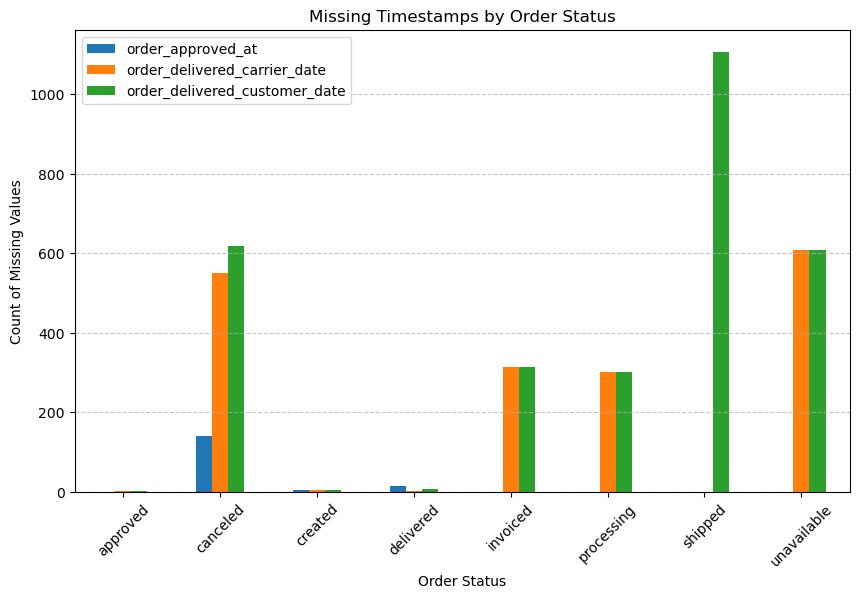

In [23]:
missing_order_summary.plot(kind="bar", figsize=(10,6))
plt.title("Missing Timestamps by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Count of Missing Values")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [24]:
# Filter for "shipped" orders
mask = (
    (orders["order_status"] == "shipped") &
    (orders["order_delivered_carrier_date"].notnull()) &
    (orders["order_delivered_customer_date"].isnull())
)

shipped_in_transit = orders[mask]

In [25]:
shipped_in_transit[["order_id", "order_delivered_carrier_date", "order_delivered_customer_date", "order_status"]].head(10)


,order_id,order_delivered_carrier_date,order_delivered_customer_date,order_status
44,ee64d42b8cf066f35eac1cf57de1aa85,2018-06-05 14:32:00,NaT,shipped
154,6942b8da583c2f9957e990d028607019,2018-01-11 19:39:23,NaT,shipped
162,36530871a5e80138db53bcfd8a104d90,2017-05-11 13:21:47,NaT,shipped
231,4d630f57194f5aba1a3d12ce23e71cd9,2017-11-22 17:28:34,NaT,shipped
299,3b4ad687e7e5190db827e1ae5a8989dd,2018-07-04 15:20:00,NaT,shipped
305,b68d69564a79dea4776afa33d1d2fcab,2018-03-05 16:10:13,NaT,shipped
333,f373335aac9a659de916f7170b8bc07a,2018-03-20 21:08:28,NaT,shipped
374,5869074071e0f56e9085dc3742c97b2a,2018-06-12 14:09:00,NaT,shipped
430,6147a4d49752afd35a119d794e481588,2017-05-02 15:29:33,NaT,shipped
444,95e42e6aaf6264cd3e77c06b32dc3003,2017-11-24 19:07:43,NaT,shipped


**Observations from Missing Delivery Timestamp Analysis**
* Missing delivery-related timestamps were not randomly distributed across orders and instead aligned closely with specific `order_status` values.
* Orders with statuses such as `canceled`, `unavailable`, and `created` frequently lacked delivery timestamps because they did not complete the fulfillment process, suggesting that these missing values reflect valid operational outcomes rather than data quality issues.
* A subset of orders labeled as `shipped` contained carrier delivery timestamps but lacked customer delivery timestamps, indicating that these orders were likely still in transit at the time of data capture.
* Because the missing timestamps appear to contain meaningful lifecycle information, these records were retained rather than removed during cleaning.

#### 5.4.2 Product Description Attributes
Missing values in the products dataset are concentrated in descriptive attributes rather than physical dimensions. Product category fields are filled with an explicit unknown_category label to preserve records while retaining information about missing metadata. For numeric descriptive and physical attributes, missing values are minimal and are imputed using the median to maintain scale without introducing outliers.

In [26]:
products_with_translation

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_clean,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225.0,16.0,10.0,14.0,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000.0,30.0,18.0,20.0,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154.0,18.0,9.0,15.0,esporte lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371.0,26.0,4.0,26.0,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625.0,20.0,17.0,13.0,utilidades domesticas,housewares
...,...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45,67,2,12300.0,40.0,40.0,40.0,moveis decoracao,furniture_decor
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41,971,1,1700.0,16.0,19.0,16.0,construcao ferramentas iluminacao,construction_tools_lights
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50,799,1,1400.0,27.0,7.0,27.0,cama mesa banho,bed_bath_table
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60,156,2,700.0,31.0,13.0,20.0,informatica acessorios,computers_accessories


In [27]:
# Fill other null info columns
desc_cols = ['product_name_length', 'product_description_length', 'product_photos_qty']
for col in desc_cols:
    products_with_translation[col] = products_with_translation[col].fillna(products_with_translation[col].median())

# Fill physical attributes
phys_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in phys_cols:
    products_with_translation[col] = products_with_translation[col].fillna(products_with_translation[col].median())

# Sanity check
products_with_translation.isnull().sum()

product_id                       0
product_category_name            0
product_name_length              0
product_description_length       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_clean      0
product_category_name_english    0
dtype: int64

**Observations from Product Attribute Imputation**
* Missing values in the `products_with_translation` dataset are concentrated primarily in descriptive metadata fields rather than core product identifiers.
* Product category missingness was preserved using an explicit `unknown_category` label rather than removing records, allowing incomplete products to remain available for downstream analysis.
* Numeric missing values were limited in frequency and primarily affected product description and physical measurement attributes, making median imputation a reasonable strategy for preserving dataset completeness without heavily distorting distributions.

### 5.5 Outlier Identification and Inspection
Potential outliers were identified and inspected to understand their distribution, magnitude, and possible business context. At this stage, no values were capped or removed. Several extreme observations appear plausible but require additional category-level and contextual analysis, which is deferred to the exploratory data analysis phase. This approach avoids premature assumptions and ensures that any future treatment decisions are informed by domain and behavioral patterns rather than distribution shape alone.

In [28]:
def detect_outliers_iqr(df):
    """
    Computes the proportion of IQR-based outliers in each numeric column
    to highlight variables with heavy-tailed distributions.
    """
    rows = []

    for col in df.select_dtypes(include=["number"]).columns:
        s = df[col].dropna()
        if s.empty:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0:
            outlier_count = 0
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outlier_count = ((s < lower) | (s > upper)).sum()

        rows.append({
            "Column": col,
            "Outlier_%": outlier_count / len(s) * 100
        })

    return pd.DataFrame(rows)

In [29]:
outlier_reports = {}

for name, data in all_dfs_dict.items():
    outlier_reports[name] = detect_outliers_iqr(data)

combined_outliers = (
    pd.concat(outlier_reports, names=["Dataset"])
    .reset_index(level=0)
    .rename(columns={"level_0": "Dataset"})
)

# Sort
combined_outliers = combined_outliers.sort_values(
    "Outlier_%",
    ascending=False
).reset_index(drop=True)

# Stylize
styled_outliers = (
    combined_outliers.style
    .format({"Outlier_%": "{:.2f}%"})
    .background_gradient(axis=0,
                        gmap = combined_outliers["Outlier_%"],
                        cmap="YlOrRd"
                        )
)

styled_outliers

,Dataset,Column,Outlier_%
0,geolocation,geolocation_lat,16.82%
1,order_reviews,review_score,14.69%
2,products_with_translation,product_weight_g,13.81%
3,order_items,freight_value,10.77%
4,order_payments,payment_value,7.68%
5,order_items,price,7.48%
6,products_with_translation,product_description_length,6.60%
7,order_payments,payment_installments,6.08%
8,products_with_translation,product_height_cm,5.74%
9,geolocation,geolocation_lng,4.23%


#### 5.5.1 Geolocation Outliers
Unlike other numeric fields, latitude and longitude values are constrained by physical geography. As a result, geographic outliers may indicate invalid coordinates rather than natural variation and therefore require additional validation prior to spatial analysis.

##### Country Level Outliers

In [30]:
geolocation.describe()

,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06
mean,-2.117615e+01,-4.639054e+01
std,5.715866e+00,4.269748e+00
min,-3.660537e+01,-1.014668e+02
25%,-2.360355e+01,-4.857317e+01
50%,-2.291938e+01,-4.663788e+01
75%,-1.997962e+01,-4.376771e+01
max,4.506593e+01,1.211054e+02


Brazil’s national territory spans approximately from 5°16′ N to 33°44′ S latitude and from 34°47′ W to 73°59′ W longitude, based on official geographic references. Because latitude and longitude are physically bounded, coordinates falling outside these ranges are treated as invalid rather than extreme values.
To ensure geographic integrity, latitude and longitude values are filtered to Brazil’s national territory prior to mapping and distance-based analysis.

In [31]:
geo_clean = geolocation[
    (geolocation['geolocation_lat'].between(-33.44, 5.16)) &
    (geolocation['geolocation_lng'].between(-73.59, -34.47))
].copy()

In [32]:
# sanity check to see if filtered latitude and longitudes fell within range
geo_clean[['geolocation_lat', 'geolocation_lng']].describe()

,geolocation_lat,geolocation_lng
count,999867.000000,999867.000000
mean,-21.174642,-46.389640
std,5.705026,4.259872
min,-33.179871,-72.930746
25%,-23.603332,-48.570601
50%,-22.919256,-46.637768
75%,-19.979430,-43.766853
max,4.482242,-34.793685


In [33]:
geo_clean.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,city_clean_name,state_clean_name
0,01037,-23.545621,-46.639292,sao paulo,SP,sao paulo,sp
1,01046,-23.546081,-46.644820,sao paulo,SP,sao paulo,sp
2,01046,-23.546129,-46.642951,sao paulo,SP,sao paulo,sp
3,01041,-23.544392,-46.639499,sao paulo,SP,sao paulo,sp
4,01035,-23.541578,-46.641607,sao paulo,SP,sao paulo,sp


While country-level filtering removes geographically invalid coordinates, it does not capture localized inconsistencies within ZIP code regions. A second inspection is therefore performed at the ZIP-code level to identify unusually large coordinate ranges that could affect downstream geographic aggregation and merge reliability.

##### Zip-Code Level Outliers

In [34]:
geo_range = (
    geo_clean
    .groupby('geolocation_zip_code_prefix')
    .agg(
        lat_min=('geolocation_lat', 'min'),
        lat_max=('geolocation_lat', 'max'),
        lng_min=('geolocation_lng', 'min'),
        lng_max=('geolocation_lng', 'max'),
        lat_range=('geolocation_lat', lambda x: x.max() - x.min()),
        lng_range=('geolocation_lng', lambda x: x.max() - x.min()),
        count=('geolocation_lat', 'size')
    )
    .reset_index()
)
geo_range.head()

,geolocation_zip_code_prefix,lat_min,lat_max,lng_min,lng_max,lat_range,lng_range,count
0,01001,-23.551427,-23.549292,-46.634410,-46.633559,0.002135,0.000850,26
1,01002,-23.548878,-23.544641,-46.636361,-46.633180,0.004237,0.003181,13
2,01003,-23.549083,-23.548901,-46.637157,-46.634862,0.000183,0.002295,17
3,01004,-23.550765,-23.549181,-46.635371,-46.634057,0.001584,0.001314,22
4,01005,-23.549980,-23.548758,-46.638411,-46.634768,0.001222,0.003643,25


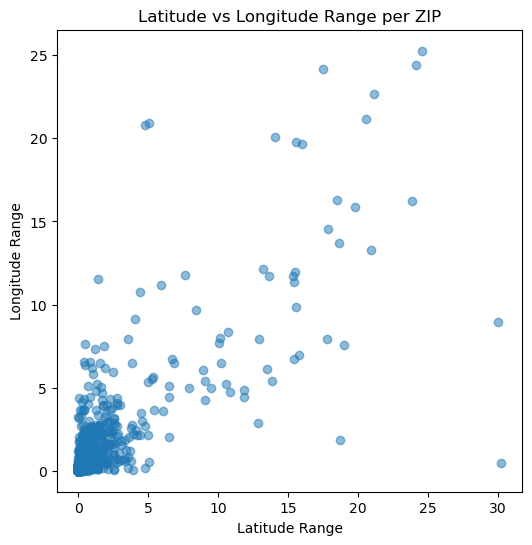

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(geo_range['lat_range'], geo_range['lng_range'], alpha=0.5)
plt.title("Latitude vs Longitude Range per ZIP")
plt.xlabel("Latitude Range")
plt.ylabel("Longitude Range")
plt.show()

Most ZIP code regions exhibit relatively small latitude and longitude ranges, producing a dense cluster near the lower-left portion of the distribution. This pattern is expected, since ZIP-level geographic coordinates should generally remain spatially localized.

A small number of ZIP codes display substantially larger coordinate ranges. To better understand these cases, the ZIP codes associated with the highest number of distinct city names were inspected as targeted sanity checks. Although these examples exhibit greater geographic spread, they represent only a small fraction of ZIP code regions and are unlikely to materially affect downstream geographic aggregation.

In [36]:
geo_zip_city = (
    geo_clean
    .groupby(['geolocation_zip_code_prefix', 'city_clean_name'])
    .agg(
        lat_range=('geolocation_lat', lambda x: x.max() - x.min()),
        lng_range=('geolocation_lng', lambda x: x.max() - x.min()),
        count=('geolocation_lat', 'size')
    )
    .reset_index()
)

In [37]:
zip_city_counts = (
    geo_clean
    .groupby('geolocation_zip_code_prefix')['city_clean_name']
    .nunique()
)

In [38]:
zip_city_counts.sort_values(ascending=False).head(10)

geolocation_zip_code_prefix
45936    4
65935    4
09780    3
85139    3
85575    3
72270    3
25936    3
76954    3
42841    3
36206    3
Name: city_clean_name, dtype: int64

In [39]:
geo_clean.loc[
    geo_clean['geolocation_zip_code_prefix'] == '45936',
    ['geolocation_zip_code_prefix', 'city_clean_name', 'geolocation_lat', 'geolocation_lng']
].drop_duplicates().sort_values('city_clean_name')

,geolocation_zip_code_prefix,city_clean_name,geolocation_lat,geolocation_lng
694790,45936,itabata,-17.999945,-39.868270
694792,45936,itabata,-12.903227,-38.308831
694905,45936,itabata,-18.000329,-39.867793
694910,45936,itabata,-12.807618,-38.395391
694939,45936,itabata,-18.010597,-39.864476
694996,45936,itabata,-18.006772,-39.863218
695000,45936,itabata,-14.670199,-40.489571
695014,45936,itabata,-12.921859,-38.441688
695098,45936,itabata,-17.998612,-39.863092
695384,45936,itabata,-12.971700,-38.513649


This initial inspection shows that the selected ZIP code is associated with a small set of closely related city names, including variations such as `itabata`, `itabatan`, `mucuri`, and `mucuri itabatan`. These patterns suggest that the unusually large coordinate spread is driven primarily by naming inconsistencies and neighboring municipal regions rather than invalid geographic records.

A more detailed investigation of city-level naming inconsistencies is deferred to the feature engineering stage, where additional standardization and validation steps are performed.

In [40]:
geo_clean.loc[
    geo_clean['geolocation_zip_code_prefix'] == '65935',
    ['geolocation_zip_code_prefix', 'city_clean_name', 'geolocation_lat', 'geolocation_lng']
].drop_duplicates().sort_values('city_clean_name')

,geolocation_zip_code_prefix,city_clean_name,geolocation_lat,geolocation_lng
763374,65935,buritirama,-5.588775,-47.013921
762292,65935,buritirana,-5.591866,-47.016824
762378,65935,buritirana,-5.591532,-47.012363
762698,65935,buritirana,-5.590068,-47.015884
763308,65935,buritirana,-5.597326,-47.015020
762405,65935,senador la rocque,-5.438624,-47.303347
762489,65935,senador la rocque,-5.431703,-47.293686
762762,65935,senador la rocque,-5.452368,-47.283464
762882,65935,senador la rocque,-5.452148,-47.283672
762914,65935,senador la rocque,-5.446706,-47.297679


This inspection revealed a more mixed pattern than the previous example. Some city names appear to reflect spelling inconsistencies, such as `senador la rocque` and `senador la roque`, while others, including `buritirama` and `buritirana`, appear to represent distinct neighboring municipalities.

Despite these differences, the associated coordinates remain relatively geographically clustered, suggesting that the observed spread likely reflects a combination of naming inconsistencies and nearby municipalities sharing the same ZIP code prefix rather than invalid geographic records.

In [41]:
geo_clean_deduped = geo_clean.drop_duplicates()

# Aggregate ZIP-level coordinates using median to mitigate outlier influence
geo_zip = (
    geo_clean_deduped
    .rename(columns={'geolocation_zip_code_prefix': 'zip_code_prefix'})
    .groupby('zip_code_prefix', as_index=False)
    .agg(
        zip_lat=('geolocation_lat', 'median'),
        zip_lng=('geolocation_lng', 'median')
    )
)
print(f"Unique ZIPs: {geo_zip['zip_code_prefix'].nunique()}")
print(f"Rows: {len(geo_zip)}")

Unique ZIPs: 19008
Rows: 19008


**Observations from Geolocation Outlier Inspection**
* Latitude and longitude values falling outside Brazil’s geographic boundaries were treated as invalid coordinates rather than statistical extremes and removed prior to spatial analysis.
* Inspection of selected high-variance ZIP codes showed that unusually large coordinate ranges could be associated with multiple municipalities sharing the same ZIP code prefix.
* Additional variation was introduced by minor inconsistencies in city naming conventions, even after text normalization.
* Because these patterns appeared to reflect real geographic structure rather than widespread corruption, ZIP-level coordinates were retained and aggregated using the median to reduce sensitivity to extreme coordinate values.

#### 5.5.2 Order Review Outliers
Outlier inspection for the `order_reviews` dataset focuses on numeric review fields, particularly `review_score`. Because review scores are bounded and reflect subjective customer feedback, extreme values are examined to confirm whether they represent valid behavior rather than data quality issues.

In [42]:
order_reviews['review_score'].describe()

count     99224.0
mean     4.086421
std      1.347579
min           1.0
25%           4.0
50%           5.0
75%           5.0
max           5.0
Name: review_score, dtype: Float64

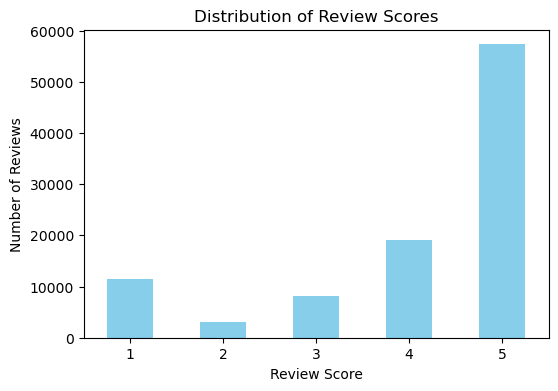

In [43]:
order_reviews['review_score'].value_counts().sort_index().plot(
    kind='bar', color='skyblue', figsize=(6,4)
)
plt.title('Distribution of Review Scores')
plt.xticks(rotation=0)
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

**Observations from Review Score Inspection**
* The IQR method initially flagged potential outliers in the `review_score` column due to the highly skewed distribution of customer ratings.
* Further inspection showed that all review scores fell within the valid rating range of 1 to 5, indicating that the flagged observations reflected legitimate customer behavior rather than invalid data.
* Because review scores are both bounded and subjective, extreme values were retained without modification.

#### 5.5.3 Product Attribute Outliers
To evaluate whether extreme product attribute values reflect data quality issues or plausible category-level variation, a targeted sanity check is performed using the lower (1st percentile) and upper (99th percentile) tails of selected product attributes. Product categories within these extreme ranges are reviewed to identify obvious mismatches, such as unusually heavy items appearing among lightweight categories or vice versa.

Because product weight exhibited the highest outlier rate among product-related attributes, it is used as the primary inspection variable. Physical dimensions, including product length, height, and width, are examined as supporting context to assess whether extreme weights align with plausible product sizes.

This inspection is intended to flag clear anomalies rather than provide a comprehensive category-level analysis.

In [44]:
product_dimensions = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
products_with_translation[product_dimensions].describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.000000,32951.000000,32951.000000,32951.000000
mean,2276.376802,30.814725,16.937422,23.196534
std,4281.926387,16.914005,13.637175,12.078707
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


In [45]:
# Define Small Thresholds to check the product categories
low_threshold = products_with_translation['product_weight_g'].quantile(0.01)
low_weight_products = products_with_translation[products_with_translation['product_weight_g'] < low_threshold]

low_weight_counts = (
    low_weight_products['product_category_name_english']
    .value_counts()
    .rename("Count")
    .reset_index()
)

styled_low_weight = (
    low_weight_counts.style
    .background_gradient(axis = 0, gmap = low_weight_counts["Count"],cmap="Blues")
    .format({"Count": "{:,}"})
)

styled_low_weight

,product_category_name_english,Count
0,telephony,59
1,auto,51
2,fashion_bags_accessories,39
3,health_beauty,28
4,computers_accessories,22
5,perfumery,17
6,sports_leisure,12
7,furniture_decor,10
8,home_appliances,10
9,baby,9


In [46]:
high_threshold =products_with_translation['product_weight_g'].quantile(0.99)
high_weight_products = products_with_translation[products_with_translation['product_weight_g'] > high_threshold]

high_weight_counts = (
    high_weight_products['product_category_name_english']
    .value_counts()
    .rename("Count")
    .reset_index()
)

styled_high_weight = (
    high_weight_counts.style
    .background_gradient(axis = 0, gmap = high_weight_counts["Count"],cmap="Blues")
    .format({"Count": "{:,}"})
)

styled_high_weight

,product_category_name_english,Count
0,sports_leisure,39
1,furniture_decor,38
2,health_beauty,35
3,housewares,27
4,office_furniture,22
5,auto,21
6,baby,17
7,furniture_living_room,16
8,bed_bath_table,14
9,kitchen_dining_laundry_garden_furniture,13


To validate that extreme product weights align with physical size, average and median dimensions are compared between the lowest 1% and highest 1% of product weights. This serves as an additional sanity check, as no obvious category-level mismatches were observed within either group.

In [47]:
comparison = pd.DataFrame({
    'Group': ['Light (1%)', 'Heavy (99%)'],
    'Mean_Length_cm': [low_weight_products['product_length_cm'].mean(), high_weight_products['product_length_cm'].mean()],
    'Mean_Height_cm': [low_weight_products['product_height_cm'].mean(), high_weight_products['product_height_cm'].mean()],
    'Mean_Width_cm': [low_weight_products['product_width_cm'].mean(), high_weight_products['product_width_cm'].mean()],
    'Median_Length_cm': [low_weight_products['product_length_cm'].median(), high_weight_products['product_length_cm'].median()],
    'Median_Height_cm': [low_weight_products['product_height_cm'].median(), high_weight_products['product_height_cm'].median()],
    'Median_Width_cm': [low_weight_products['product_width_cm'].median(), high_weight_products['product_width_cm'].median()],
})
comparison.head()

,Group,Mean_Length_cm,Mean_Height_cm,Mean_Width_cm,Median_Length_cm,Median_Height_cm,Median_Width_cm
0,Light (1%),21.177370,9.721713,16.220183,18.0,6.0,13.0
1,Heavy (99%),61.036364,54.221212,48.272727,60.0,55.0,50.0


**Observations from Product Attribute Inspection**
* Product-level outliers were examined using multiple sanity checks, including percentile-based comparisons, category review, and consistency between product weight and physical dimensions.
* These checks did not reveal implausible category combinations or clear data quality concerns within the inspected extreme ranges.
* Heavier products also tended to exhibit substantially larger physical dimensions, supporting the plausibility of the observed weight distribution.
* Because the inspected extremes aligned with reasonable product-level variation, product attributes were retained without additional outlier treatment during the wrangling stage.

#### 5.5.4 Order Item Cost Outliers
The `order_items` dataset contains transaction-level cost variables with substantial variation, particularly `price` and `freight_value`. Because these fields are naturally influenced by product type, shipping distance, and fulfillment complexity, extreme values are inspected to determine whether they reflect plausible marketplace behavior or potential data quality concerns.

In [48]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [49]:
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


Because `freight_value` is highly right-skewed and contains several extreme upper values, the highest freight charges are reviewed separately as a targeted sanity check.

In [50]:
high_freight_threshold = order_items['freight_value'].quantile(0.99)
high_freight_items = order_items[order_items['freight_value'] > high_freight_threshold]

high_freight_items[['price', 'freight_value']].describe()
high_freight_items.sort_values('freight_value', ascending=False).head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
73486,a77e1550db865202c56b19ddc6dc4d53,1,ec31d2a17b299511e7c8627be9337b9b,257e61d3251fb5efb9daadddbc2cf7ca,2018-04-25 06:55:13,979.00,409.68
28044,3fde74c28a3d5d618c00f26d51baafa0,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-22 03:15:09,2338.08,375.28
3303,076d1555fb53a89b0ef4d529e527a0f6,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-07 04:35:22,2338.08,375.28
69797,9f49bd16053df810384e793386312674,1,256a9c364b75753b97bee410c9491ad8,5c030029b5916fed0986310385ec9009,2018-08-02 03:44:28,1149.00,339.59
16731,264a7e199467906c0727394df82d1a6a,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-04-23 17:15:10,1050.00,338.30
87936,c7a07ddd52bbe18b61da49a8d89853d3,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-07-31 10:45:11,1050.00,322.10
5037,0b6230647ed16f4b3e70282dc4b5b87f,1,46e24ce614899e36617e37ea1e4aa6ff,17f51e7198701186712e53a39c564617,2018-06-01 19:14:24,1050.00,321.88
3584,0822bcde10bb5d023755a71bc8f7797f,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2018-05-10 23:52:39,990.00,321.46
29787,43bdbd9dc0931d72befdf4765af6c442,1,7e53e051875b2a0c9f22acd8a9a29a20,eeb6de78f79159600292e314a77cbd18,2018-07-12 08:35:21,3089.00,317.47
48320,6ddfbf514959b49b6410c01ad93054bb,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2017-11-30 15:10:57,1045.00,314.40


Inspection of the upper freight tail shows that unusually high shipping costs are generally associated with high-priced items rather than isolated anomalies. This pattern suggests that elevated freight values likely correspond to expensive, bulky, fragile, or logistically complex products.

<Axes: title={'center': 'Low Price Items (Bottom 1%)'}, xlabel='price', ylabel='freight_value'>

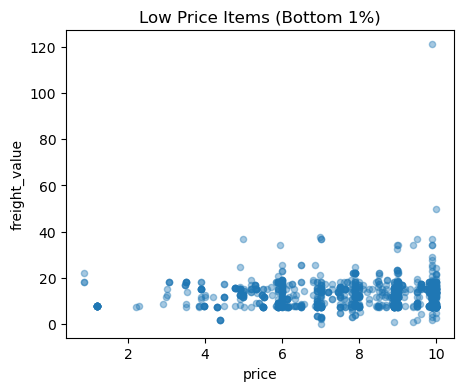

In [51]:
low_price_thr = order_items['price'].quantile(0.01)
low_price_items = order_items[order_items['price'] <= low_price_thr]

low_price_items.plot.scatter(
    x='price',
    y='freight_value',
    alpha=0.4,
    figsize=(5,4),
    title='Low Price Items (Bottom 1%)'
)

<Axes: title={'center': 'High Price Items (Top 1%)'}, xlabel='price', ylabel='freight_value'>

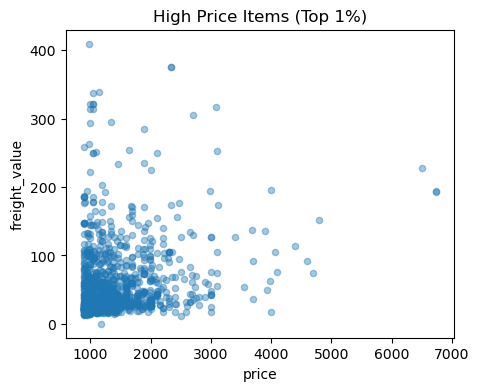

In [52]:
high_price_thr = order_items['price'].quantile(0.99)
high_price_items = order_items[order_items['price'] >= high_price_thr]

high_price_items.plot.scatter(
    x='price',
    y='freight_value',
    alpha=0.4,
    figsize=(5,4),
    title='High Price Items (Top 1%)'
)

**Observations from Order Item Cost Inspection**

* Approximately 7.5% of `price` values and 10.8% of `freight_value` entries were identified as statistical outliers using the IQR method.
* High freight charges were generally associated with high-priced items, supporting the plausibility of the observed upper-tail values.
* Lower-priced items tended to exhibit more stable freight costs, while higher-priced items showed substantially greater variability in shipping charges.
* The increasing spread between `price` and `freight_value` likely reflects differences in product characteristics, shipping requirements, and fulfillment conditions rather than widespread data quality issues.
* Because the inspected extremes appeared internally consistent, both `price` and `freight_value` outliers were retained for downstream analysis.

#### 5.5.5 Payments and Installments Outliers
In the column-level data profile, payment value, price, and payment installments were flagged due to moderate outlier rates, largely driven by high-end values rather than extreme low values. While zero values appear in a small number of records, the majority of outliers occur on the upper end of the distributions, which is expected in an e-commerce context. This section focuses on validating these edge cases to distinguish legitimate high-value transactions from potential data issues.

In [53]:
order_payments[['payment_installments', 'payment_value']].describe()

,payment_installments,payment_value
count,103886.0,103886.000000
mean,2.853349,154.100380
std,2.687051,217.494064
min,0.0,0.000000
25%,1.0,56.790000
50%,1.0,100.000000
75%,4.0,171.837500
max,24.0,13664.080000


Summary statistics show that while maximum values fall within expected ranges, the minimum value of zero for both payment value and payment installments warrants further investigation.

In [54]:
zero_payments = order_payments[order_payments["payment_value"] == 0]
len(zero_payments)

9

Only a small number of records contain a payment value of zero, suggesting these cases are isolated rather than widespread issues.

In [55]:
zero_payments['payment_type'].value_counts()

payment_type
voucher        6
not_defined    3
boleto         0
credit_card    0
debit_card     0
Name: count, dtype: int64

To better understand these zero-value payments, payment types are examined to identify whether specific methods are associated with these cases.

In [56]:
undefined_orders = order_payments.loc[
    order_payments['payment_type'] == 'not_defined', 'order_id'
]

orders[orders['order_id'].isin(undefined_orders)][['order_id', 'order_status']]

,order_id,order_status
1130,00b1cb0320190ca0daa2c88b35206009,canceled
39919,4637ca194b6387e2d538dc89b124b0ee,canceled
40235,c8c528189310eaa44a745b8d9d26908b,canceled


In [57]:
mask = (
    (order_payments['payment_type'] == 'not_defined') &
    (order_payments['payment_value'] == 0)
)

orders.loc[
    orders['order_id'].isin(order_payments.loc[mask, 'order_id']),
    'order_status'
].value_counts()

order_status
canceled       3
approved       0
created        0
delivered      0
invoiced       0
processing     0
shipped        0
unavailable    0
Name: count, dtype: int64

Cross-referencing these orders with the orders dataset shows that entries with undefined payment types correspond to canceled orders, indicating that zero payment values in these cases reflect valid cancellations rather than data errors.

In [58]:
if 'canceled_zero_payment' not in order_payments['payment_type'].cat.categories:
    order_payments['payment_type'] = (
        order_payments['payment_type']
        .cat.add_categories(['canceled_zero_payment'])
    )

order_payments.loc[mask, 'payment_type'] = 'canceled_zero_payment'

In [59]:
# sanity check
order_payments['payment_type'].value_counts()

payment_type
credit_card              76795
boleto                   19784
voucher                   5775
debit_card                1529
canceled_zero_payment        3
not_defined                  0
Name: count, dtype: int64

In [60]:
zero_installments = order_payments[order_payments["payment_installments"] == 0]
len(zero_installments)

2

In [61]:
zero_installments['payment_type'].value_counts()

payment_type
credit_card              2
boleto                   0
debit_card               0
not_defined              0
voucher                  0
canceled_zero_payment    0
Name: count, dtype: int64

In [62]:
zero_installments_summary = zero_installments.merge(
    orders[['order_id', 'order_status']], on='order_id', how='left'
)
zero_installments_summary[['payment_type', 'payment_value', 'order_status']].value_counts()

payment_type           payment_value  order_status
credit_card            58.69          delivered       1
                       129.94         delivered       1
                       58.69          approved        0
                                      canceled        0
                                      created         0
                                      invoiced        0
                                      processing      0
                                      shipped         0
                                      unavailable     0
boleto                 58.69          delivered       0
                                      approved        0
                                      canceled        0
                                      created         0
                                      invoiced        0
                                      processing      0
                                      shipped         0
                                      unavailable    

In [63]:
order_payments.loc[
    (order_payments['payment_installments'] == 0) &
    (order_payments['payment_type'] == 'credit_card') &
    (order_payments['payment_value'] > 0),
    'payment_installments'
] = 1

Two records had payment_installments = 0 despite having valid payment values and being marked as delivered. These cases corresponded to credit card payments, which should always have at least one installment. Therefore, the installment count for these records was corrected from 0 to 1.

<Figure size 1000x600 with 0 Axes>

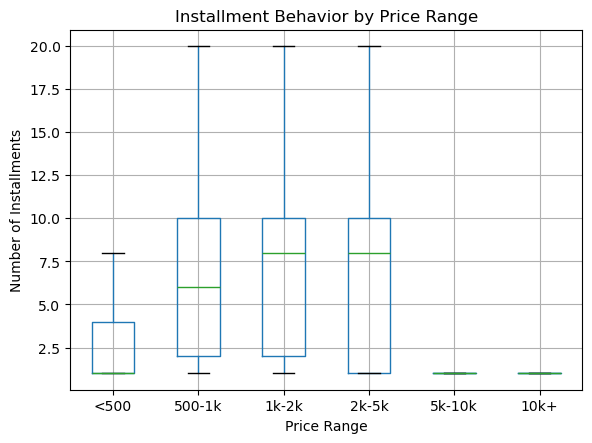

In [64]:
order_payments['price_range'] = pd.cut(
    order_payments['payment_value'],
    bins=[-0.01, 500, 1000, 2000, 5000, 10000, 20000],
    labels=['<500', '500-1k', '1k-2k', '2k-5k', '5k-10k', '10k+']
)

plt.figure(figsize=(10,6))
order_payments.boxplot(column='payment_installments', by='price_range', showfliers=False)
plt.title('Installment Behavior by Price Range')
plt.suptitle('')
plt.xlabel('Price Range')
plt.ylabel('Number of Installments')
plt.show()

To provide context for the observed installment patterns, the distribution of orders across price ranges is shown below.

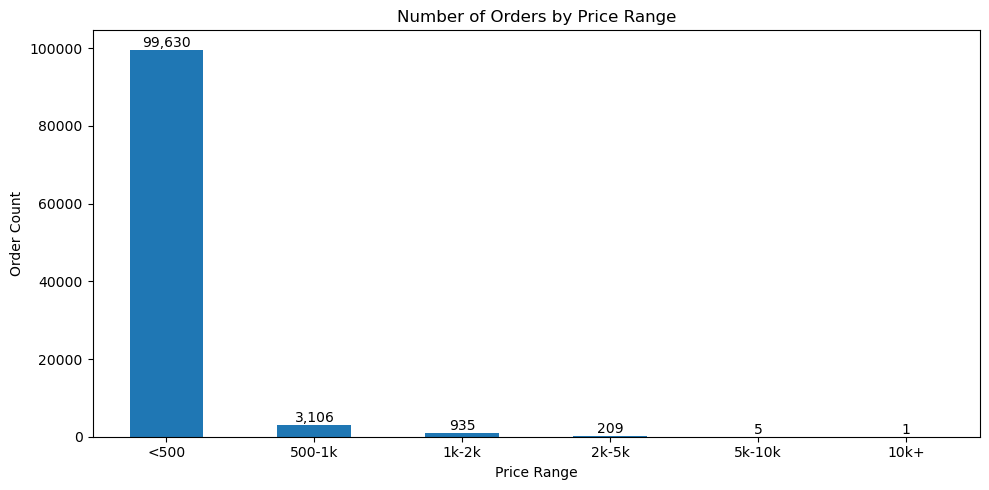

In [65]:
price_range_counts = (
    order_payments['price_range']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))
ax = price_range_counts.plot(kind='bar')

plt.title('Number of Orders by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Order Count')
plt.xticks(rotation=0)

for i, value in enumerate(price_range_counts):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Observations from Payment and Installment Inspection**
* Zero-value payments were rare and were associated primarily with canceled orders and undefined payment types, indicating valid operational outcomes rather than data corruption.
* A small subset of records with `payment_installments = 0` and positive `payment_value` were identified as inconsistent credit card transactions and corrected to a single installment.
* Most payment records were concentrated within lower price ranges, while high-value transactions represented only a very small proportion of total orders.
* Installment counts generally increased alongside payment value, suggesting that installment behavior reflects expected purchasing patterns for higher-cost transactions.
* Although `payment_value` and `payment_installments` were flagged as statistical outliers, the observed upper-tail values appeared plausible within the context of e-commerce purchasing behavior and were retained for downstream analysis.

### 5.6 Duplicate Check
Before merging the datasets, duplicate checks are performed to confirm that each table adheres to its expected level of uniqueness and does not contain unintended repeated records that could distort aggregations or downstream joins.

In [66]:
# Update the dictionary with cleaned dataframes
all_dfs_dict = {
    "sellers": sellers,
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "geolocation": geo_zip,  # updated with aggregated ZIP-level coordinates
    "order_payments": order_payments,  # updated with cleaned payments
    "order_reviews": order_reviews,
    "products_with_translation": products_with_translation,  # updated with filled nulls and translation
}

# Check for duplicates in each data set
for name, df in all_dfs_dict.items():
    dup_count = df.duplicated().sum()
    print(f"{name}: {dup_count} duplicate rows")
    if dup_count > 0:
        display(df[df.duplicated()])

sellers: 0 duplicate rows
orders: 0 duplicate rows
order_items: 0 duplicate rows
customers: 0 duplicate rows
geolocation: 0 duplicate rows
order_payments: 0 duplicate rows
order_reviews: 0 duplicate rows
products_with_translation: 0 duplicate rows


**Observations from Duplicate Inspection**
* No fully duplicated rows were identified across any dataset included in the analysis pipeline.
* Duplicate checks were performed after key preprocessing steps, including geolocation aggregation, missing value handling, and payment corrections.
* Confirming dataset uniqueness prior to merging helps reduce the risk of row inflation and distorted summary statistics during downstream integration and analysis.

### 5.7 Data Cleaning and Standardization Summary

This section focused on improving dataset consistency, validating data quality, and preparing the tables for reliable integration. Text normalization, category translation, and dtype standardization were applied to reduce formatting inconsistencies and establish a cleaner analytical structure across datasets.

Missing values and statistical outliers were examined contextually rather than removed automatically. In several cases, seemingly unusual records reflected valid operational behavior, including canceled orders, in-transit shipments associated with missing `order_delivered_customer_date` values, geographically dispersed ZIP code regions, and high-value transactions. Where corrections were necessary, adjustments were limited to clearly inconsistent records, such as invalid `payment_installments` counts for completed credit card purchases.

Targeted sanity checks across geographic, transactional, review, payment, and product-related fields did not reveal widespread corruption or implausible relationships. As a result, the majority of extreme observations in variables such as `product_weight_g`, `freight_value`, `payment_value`, and `review_score` were retained to preserve meaningful marketplace variation prior to exploratory analysis and feature engineering.

Final duplicate checks confirmed that the cleaned datasets maintained their expected granularity and were ready for downstream merging and analytical workflows.

## 6. Constructing the Final Order-Item-Level Dataset

This section combines the cleaned datasets into a unified order-item-level analytical table. Aggregation, restructuring, geolocation integration, feature engineering, and merge operations are performed in a structured sequence to preserve relational integrity while progressively enriching each record with geographic, transactional, product, payment, review, fulfillment, and seller profile information.

### 6.1 Adding Geolocation Information for Sellers and Customers
Geolocation data is added to seller and customer records using ZIP-level median coordinates. For records without ZIP code matches, missing coordinates are filled using city-level medians, followed by state-level medians as a final fallback.

To support this hierarchical filling strategy, median latitude and longitude values are first computed at the city and state levels. These aggregated references are later used to fill remaining missing coordinates after ZIP-level merges.

In [67]:
# Optional fallback: city-level median coordinates
geo_city = (
    geo_clean_deduped
    .groupby(['city_clean_name', 'state_clean_name'], as_index=False)
    .agg(
        city_lat=('geolocation_lat', 'median'),
        city_lng=('geolocation_lng', 'median')
    )
)

# Optional fallback: state-level median coordinates
geo_state = (
    geo_clean_deduped
    .groupby('state_clean_name', as_index=False)
    .agg(
        state_lat=('geolocation_lat', 'median'),
        state_lng=('geolocation_lng', 'median')
    )
)

#### Geolocation for Customers

In [68]:
# Merge ZIP-level median coordinates
customers_geo = customers.merge(
    geo_zip,
    left_on='customer_zip_code_prefix',
    right_on='zip_code_prefix',
    how='left'
)

# Fill missing ZIP coordinates with city-level median coordinates
customers_geo = customers_geo.merge(
    geo_city,
    on=['city_clean_name', 'state_clean_name'],
    how='left'
)

customers_geo['customer_lat'] = customers_geo['zip_lat'].fillna(customers_geo['city_lat'])
customers_geo['customer_lng'] = customers_geo['zip_lng'].fillna(customers_geo['city_lng'])

# Fill remaining missing coordinates with state-level median coordinates
customers_geo = customers_geo.merge(
    geo_state,
    on='state_clean_name',
    how='left'
)

customers_geo['customer_lat'] = customers_geo['customer_lat'].fillna(customers_geo['state_lat'])
customers_geo['customer_lng'] = customers_geo['customer_lng'].fillna(customers_geo['state_lng'])

# Clean up helper columns
customers_geo = customers_geo.drop(
    columns=[
        'customer_city',
        'customer_state',
        'zip_code_prefix',
        'zip_lat',
        'zip_lng',
        'city_lat',
        'city_lng',
        'state_lat',
        'state_lng'
    ],
    errors='ignore'
)

# Rename normalized location columns
customers_geo = customers_geo.rename(columns={
    'city_clean_name': 'customer_city_clean_name',
    'state_clean_name': 'customer_state_clean_name'
})

In [69]:
# Sanity check
customers_geo.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                99441 non-null  string 
 1   customer_unique_id         99441 non-null  string 
 2   customer_zip_code_prefix   99441 non-null  string 
 3   customer_city_clean_name   99441 non-null  string 
 4   customer_state_clean_name  99441 non-null  string 
 5   customer_lat               99441 non-null  float64
 6   customer_lng               99441 non-null  float64
dtypes: float64(2), string(5)
memory usage: 13.0 MB


#### Geolocation for Sellers

In [70]:
# Merge ZIP-level median coordinates
sellers_geo = sellers.merge(
    geo_zip,
    left_on='seller_zip_code_prefix',
    right_on='zip_code_prefix',
    how='left'
)

# Fill missing ZIP coordinates with city-level median coordinates
sellers_geo = sellers_geo.merge(
    geo_city,
    on=['city_clean_name', 'state_clean_name'],
    how='left'
)

sellers_geo['seller_lat'] = sellers_geo['zip_lat'].fillna(sellers_geo['city_lat'])
sellers_geo['seller_lng'] = sellers_geo['zip_lng'].fillna(sellers_geo['city_lng'])

# Fill remaining missing coordinates with state-level median coordinates
sellers_geo = sellers_geo.merge(
    geo_state,
    on='state_clean_name',
    how='left'
)

sellers_geo['seller_lat'] = sellers_geo['seller_lat'].fillna(sellers_geo['state_lat'])
sellers_geo['seller_lng'] = sellers_geo['seller_lng'].fillna(sellers_geo['state_lng'])

# Clean up helper columns
sellers_geo = sellers_geo.drop(
    columns=[
        'seller_city',
        'seller_state',
        'zip_code_prefix',
        'zip_lat',
        'zip_lng',
        'city_lat',
        'city_lng',
        'state_lat',
        'state_lng'
    ],
    errors='ignore'
)

# Rename normalized location columns
sellers_geo = sellers_geo.rename(columns={
    'city_clean_name': 'seller_city_clean_name',
    'state_clean_name': 'seller_state_clean_name'
})

In [71]:
# Sanity check
sellers_geo.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   seller_id                3095 non-null   string 
 1   seller_zip_code_prefix   3095 non-null   string 
 2   seller_city_clean_name   3095 non-null   string 
 3   seller_state_clean_name  3095 non-null   string 
 4   seller_lat               3095 non-null   float64
 5   seller_lng               3095 non-null   float64
dtypes: float64(2), string(4)
memory usage: 293.8 KB


**Observations from Geolocation Integration**
* Hierarchical geolocation filling was performed using ZIP-level, city-level, and state-level median coordinates to minimize missing geographic information.
* ZIP-level coordinates provided the primary geographic reference, while city- and state-level aggregates served as fallback strategies for unmatched records.
* Median aggregation was used throughout the workflow to reduce sensitivity to extreme coordinate values and localized geographic variation.
* After integration, both `customers_geo` and `sellers_geo` contained consistent geographic coordinates suitable for downstream merging and distance-based feature engineering.

### 6.2 Payment Structure Preparation

The `order_payments` table contains one row per payment method per order. As a result, orders paid using multiple methods, such as a combination of credit card and voucher payments, may produce duplicate rows when merged directly into an order-item-level dataset.

To preserve the intended granularity and prevent uncontrolled row duplication, payment records are aggregated prior to merging. Payment amounts are pivoted into separate columns by `payment_type`, while total payment value and installment information are retained at the order level.

In [72]:
payment_pivot = (
    order_payments
    .groupby(['order_id', 'payment_type'], observed=False)['payment_value']
    .sum()
    .unstack(fill_value=0)
)
payment_pivot.columns = [f'order_payment_{col}_amount' for col in payment_pivot.columns]
payment_pivot = payment_pivot.reset_index()

# add installments and total payment value
payment_summary = order_payments.groupby('order_id').agg(
    order_payment_installments=('payment_installments', 'max'),
    order_payment_total=('payment_value', 'sum')
).reset_index()

payment_pivot = payment_pivot.merge(payment_summary, on='order_id', how='left')
payment_pivot.head()

,order_id,order_payment_boleto_amount,order_payment_credit_card_amount,order_payment_debit_card_amount,order_payment_not_defined_amount,order_payment_voucher_amount,order_payment_canceled_zero_payment_amount,order_payment_installments,order_payment_total
0,00010242fe8c5a6d1ba2dd792cb16214,0.0,72.19,0.0,0.0,0.0,0.0,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,0.0,259.83,0.0,0.0,0.0,0.0,3,259.83
2,000229ec398224ef6ca0657da4fc703e,0.0,216.87,0.0,0.0,0.0,0.0,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,0.0,25.78,0.0,0.0,0.0,0.0,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,0.0,218.04,0.0,0.0,0.0,0.0,3,218.04


**Observations from Payment Restructuring**
* Payment amounts were pivoted into separate columns by `payment_type` to preserve multi-method payment behavior without increasing dataset granularity.
* `order_payment_total` was calculated as the sum of all payment contributions associated with each `order_id`.
* `order_payment_installments` was aggregated using the maximum installment count per order to retain the final installment structure associated with the transaction.
* Aggregating payments prior to merging helps prevent unintended row duplication during downstream joins with `order_items`.

### 6.3 Order Reviews Preparation
A small subset of orders contain multiple reviews. Because these reviews may capture different points in the customer experience, collapsing them into a single record could discard meaningful information.

Reviews are instead restructured into a wide format ordered chronologically, so that each review in a sequence is preserved as a separate set of columns rather than lost through aggregation.

In [73]:
order_reviews_ranked = (
    order_reviews
    .sort_values(['order_id', 'review_creation_date'])
    .assign(review_num=lambda x: x.groupby('order_id').cumcount() + 1)
    .rename(columns={
        'review_score': 'score',
        'review_creation_date': 'creation_date',
        'review_answer_timestamp': 'answer_timestamp',
        'review_comment_title': 'title',
        'review_comment_message': 'message'
    })
)

order_reviews_pivot = order_reviews_ranked.pivot_table(
    index='order_id',
    columns='review_num',
    values=['score', 'creation_date', 'answer_timestamp', 'title', 'message'],
    aggfunc='first'
)

order_reviews_pivot.columns = [f'order_review_{col[1]}_{col[0]}' for col in order_reviews_pivot.columns]
order_reviews_pivot = order_reviews_pivot.reset_index()
order_reviews_pivot.head()

,order_id,order_review_1_answer_timestamp,order_review_2_answer_timestamp,order_review_3_answer_timestamp,order_review_1_creation_date,order_review_2_creation_date,order_review_3_creation_date,order_review_1_message,order_review_2_message,order_review_3_message,order_review_1_score,order_review_2_score,order_review_3_score,order_review_1_title,order_review_2_title
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-22 10:57:03,NaT,NaT,2017-09-21,NaT,NaT,"Perfeito, produto entregue antes do combinado.",<NA>,<NA>,5,<NA>,<NA>,<NA>,<NA>
1,00018f77f2f0320c557190d7a144bdd3,2017-05-15 11:34:13,NaT,NaT,2017-05-13,NaT,NaT,<NA>,<NA>,<NA>,4,<NA>,<NA>,<NA>,<NA>
2,000229ec398224ef6ca0657da4fc703e,2018-01-23 16:06:31,NaT,NaT,2018-01-23,NaT,NaT,Chegou antes do prazo previsto e o produto surpreendeu pela qualidade. Muito satisfatório.,<NA>,<NA>,5,<NA>,<NA>,<NA>,<NA>
3,00024acbcdf0a6daa1e931b038114c75,2018-08-15 16:39:01,NaT,NaT,2018-08-15,NaT,NaT,<NA>,<NA>,<NA>,4,<NA>,<NA>,<NA>,<NA>
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-03-03 10:54:59,NaT,NaT,2017-03-02,NaT,NaT,Gostei pois veio no prazo determinado .,<NA>,<NA>,5,<NA>,<NA>,<NA>,<NA>


**Observations from Review Restructuring**
* Reviews were preserved chronologically using a wide-format structure so that sequential review information remained available for downstream analysis and feature engineering.
* Primary review fields such as `order_review_1_score` remain broadly populated across reviewed orders, while later review positions are naturally more sparse due to the relatively small number of orders containing multiple reviews.
* Some later review-related columns, such as `order_review_3_title`, are absent because the underlying review records did not contain values for those fields. This reflects the structure of the source data rather than incomplete processing.

### 6.4 Merge Datasets
The cleaned datasets are merged in a structured sequence to preserve order-item-level granularity while progressively enriching each record with customer, product, payment, review, seller, and geographic information.

`orders` is first joined with customer geographic information to establish a transactional base table. Additional datasets are then merged incrementally to incorporate product metadata, payment structure, review information, and seller-level geographic context without introducing unintended duplication.

The schema below summarizes the key relationships that guide the merge process and highlights where one-to-many relationships and pre-aggregated tables influence integration behavior.

*Datasets marked with an asterisk (\*) represent enriched, transformed, or restructured versions used during integration rather than the original source tables.*


```mermaid
%%{init: {'themeVariables': { 'fontSize': '10px'}}}%%
erDiagram

    CUSTOMERS* ||--o{ ORDERS : places
    ORDERS ||--o{ ORDER_ITEMS : contains
    PRODUCTS* ||--o{ ORDER_ITEMS : describes
    SELLERS* ||--o{ ORDER_ITEMS : fulfills

    ORDERS ||--|| ORDER_PAYMENTS* : has
    ORDERS ||--|| ORDER_REVIEWS* : receives

```

**Key relationship notes:**

* `orders → order_items` introduces the primary one-to-many fanout and establishes order-item-level granularity.
* `order_payments*` and `order_reviews*` represent transformed versions (`payment_pivot` and `order_reviews_pivot`) that were restructured to one row per `order_id` prior to merging.
* `customers*`, `products*`, and `sellers*` indicate enriched datasets (`customers_geo`, `products_with_translation`, and `sellers_geo`) used during integration.
* Geographic enrichment was incorporated through hierarchical ZIP-, city-, and state-level coordinate filling.

#### 6.4.1 Merge Validation Helper Function
Because the datasets operate at different levels of granularity, merge validation checks are performed throughout the integration process to monitor row counts, unique key counts, and expected fanout behavior.

The helper function below is used to validate that merges preserve the intended dataset structure and do not introduce unintended duplication.

In [74]:
def validate_merge(before_df, after_df, merge_key, expect_fanout=False, label=""):
    before_rows = before_df.shape[0]
    after_rows = after_df.shape[0]

    before_unique = before_df[merge_key].nunique()
    after_unique = after_df[merge_key].nunique()
    
    print(f"\nMerge Validation: {label}")
    print(f"  Rows before merge:           {before_rows:,}")
    print(f"  Rows after merge:            {after_rows:,}")
    print(f"  Unique {merge_key} (before): {before_unique:,}")
    print(f"  Unique {merge_key} (after):  {after_unique:,}")
    
    if before_unique != after_unique:
        warnings.warn(f"Unique {merge_key} changed after merge")
    
    if not expect_fanout:
        assert before_rows == after_rows, (
            f"Unexpected fanout! Rows changed from {before_rows:,} to {after_rows:,}"
        )
        print("  All checks passed")
    else:
        if after_rows > before_rows:
            print(f"  Expected fanout confirmed ({before_rows:,} to {after_rows:,} rows)")
        else:
            print("  No fanout detected")

#### 6.4.2 Create `orders_customers`
Merge `orders` and `customers_geo` to create a base order table.

In [75]:
orders_customers = orders.merge(
    customers_geo, 
    on = 'customer_id', 
    how ='left'
    )

# Sanity check
validate_merge(
    before_df=orders, 
    after_df=orders_customers, 
    merge_key='customer_id', 
    expect_fanout=False, 
    label="orders + customers_geo"
)


Merge Validation: orders + customers_geo
  Rows before merge:           99,441
  Rows after merge:            99,441
  Unique customer_id (before): 99,441
  Unique customer_id (after):  99,441
  All checks passed


The merge between `orders` and `customers_geo` preserved row counts and unique `customer_id` values, confirming that the integration behaved as expected without introducing duplication. This is consistent with the dataset structure, where each order is associated with a single customer record.

#### 6.4.3 Create `order_details`
Merge `orders_customers` with `order_items` to create `order_details`

In [76]:
order_details = orders_customers.merge(
    order_items, 
    on='order_id', 
    how='left'
)

# Sanity check
validate_merge(
    before_df=orders_customers, 
    after_df=order_details, 
    merge_key='order_id', 
    expect_fanout=True, 
    label="orders_customers + order_items"
    )


Merge Validation: orders_customers + order_items
  Rows before merge:           99,441
  Rows after merge:            113,425
  Unique order_id (before): 99,441
  Unique order_id (after):  99,441
  Expected fanout confirmed (99,441 to 113,425 rows)


This merge increases the row count relative to `orders_customers`, which is expected because a single order may contain multiple items. Since `order_items` stores one row per item, orders with multiple products produce multiple rows after the join.

The merge validation confirmed that the observed fanout behavior was expected and that all unique `order_id` values were preserved during the integration.

Because a left join was used, orders without associated item records were also retained. An additional inspection was performed to identify the statuses associated with these cases.

In [77]:
order_details.loc[
    order_details['order_item_id'].isna(),
    'order_status'
].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
approved         0
delivered        0
processing       0
Name: count, dtype: int64

**Note on Orders Without Items**

A subset of orders does not have associated item records following the left join between orders and order items. These cases primarily correspond to orders with statuses such as unavailable and canceled, where items were never fulfilled.

These rows are retained to preserve full order coverage. Item-level fields are null in these cases, reflecting the absence of associated items rather than missing data.

To explicitly distinguish these cases, the following flag is introduced:

In [78]:
order_details['has_items'] = order_details['order_item_id'].notna()
order_details['has_items'].value_counts()

has_items
True     112650
False       775
Name: count, dtype: int64

This enables flexible filtering for:

* item-level analysis (`has_items` == True)
* order-level analysis (`has_items` == False or aggregated by `order_id`)

The merge performed as expected. Approximately 0.68% of rows correspond to orders without associated item records. These cases are retained, as they likely represent failed or incomplete transactions and may serve as important signals when analyzing customer dissatisfaction and retention.

#### 6.4.4 Add Product Information to Order Details
Merge `order_details` and `products_with_translation`

In [79]:
before_df = order_details.copy()

order_details = order_details.merge(
    products_with_translation,
    on='product_id',
    how='left'
)

validate_merge(
    before_df=before_df,
    after_df=order_details,
    merge_key='order_id',
    expect_fanout=False,
    label="Order Details + Products"
)


Merge Validation: Order Details + Products
  Rows before merge:           113,425
  Rows after merge:            113,425
  Unique order_id (before): 99,441
  Unique order_id (after):  99,441
  All checks passed


Product information is added to `order_details` using `product_id` as the merge key. The row count and unique `order_id` values remain unchanged after the merge, confirming that product attributes were integrated without introducing unintended duplication or fanout.

#### 6.4.5 Add Payment Information to Order Details
Merge `order_details` with `payment_pivot`

In [80]:
before_df = order_details.copy()

order_details = order_details.merge(
    payment_pivot,
    on='order_id',
    how='left'
)

validate_merge(
    before_df=before_df,
    after_df=order_details,
    merge_key='order_id',
    expect_fanout=False,
    label="Order Details + Payment Pivot"
)


Merge Validation: Order Details + Payment Pivot
  Rows before merge:           113,425
  Rows after merge:            113,425
  Unique order_id (before): 99,441
  Unique order_id (after):  99,441
  All checks passed


In [81]:
payment_amount_cols = [
    col for col in order_details.columns
    if col.startswith('order_payment_') and col.endswith('_amount')
]

order_details[payment_amount_cols] = order_details[payment_amount_cols].fillna(0)

Payment information is merged using the aggregated `payment_pivot` table rather than the raw `order_payments` dataset to prevent row duplication during integration. Because `payment_pivot` contains one row per `order_id`, the merge preserves the existing order-item-level granularity, with row counts and unique `order_id` values remaining unchanged after validation.

Missing values in payment amount columns were filled with `0` to indicate that a given payment method was not used for the associated order.

*Note that payment columns are order-level attributes and will repeat across order-item rows belonging to the same order. Always aggregate to the `order_id` level before summing payment values to avoid inflation.*

#### 6.4.6 Add Review Information to Order Details
Merge `order_details` and `order_reviews_pivot`

In [82]:
before_df = order_details.copy()

order_details = order_details.merge(
    order_reviews_pivot,
    on='order_id',
    how='left'
)

validate_merge(
    before_df=before_df,
    after_df=order_details,
    merge_key='order_id',
    expect_fanout=False,
    label="Order Details + Order Reviews Pivot"
)


Merge Validation: Order Details + Order Reviews Pivot
  Rows before merge:           113,425
  Rows after merge:            113,425
  Unique order_id (before): 99,441
  Unique order_id (after):  99,441
  All checks passed


The review pivot was successfully merged with no change in row count, confirming that the integration did not introduce unintended fanout. Because a left join was used, all rows from `order_details` were preserved, including orders without associated review records.

#### 6.4.7 Add Seller Information to Order Details
Merge `order_details` and `sellers_geo`

In [83]:
before_df = order_details.copy()

order_details = order_details.merge(
    sellers_geo,
    on='seller_id',
    how='left'
)

validate_merge(
    before_df=before_df,
    after_df=order_details,
    merge_key='order_id',
    expect_fanout=False,
    label="Order Details + Sellers"
)


Merge Validation: Order Details + Sellers
  Rows before merge:           113,425
  Rows after merge:            113,425
  Unique order_id (before): 99,441
  Unique order_id (after):  99,441
  All checks passed


Seller geographic information is added to `order_details` using `seller_id` as the merge key. Row counts and unique `order_id` values remain unchanged after validation, confirming that seller attributes were integrated without introducing unintended duplication or fanout.

### 6.5 Derived Variables and Analytical Features

#### 6.5.1 Customer-Seller Distance
Distance was calculated using the Haversine formula to efficiently estimate geographic distance between customer and seller coordinates at scale. This feature provides a continuous measure of shipment length and supports later analysis of freight costs, delivery performance, and geographic purchasing patterns.

In [84]:
# Convert coordinates to radians
lat1 = np.radians(order_details['customer_lat'])
lon1 = np.radians(order_details['customer_lng'])

lat2 = np.radians(order_details['seller_lat'])
lon2 = np.radians(order_details['seller_lng'])

# Coordinate differences
dlat = lat2 - lat1
dlon = lon2 - lon1

# Haversine formula
a = (
    np.sin(dlat / 2)**2
    + np.cos(lat1)
    * np.cos(lat2)
    * np.sin(dlon / 2)**2
)

c = 2 * np.arcsin(np.sqrt(a))

# Earth radius in miles
earth_radius_miles = 3958.8

order_details['customer_seller_distance_miles'] = (
    earth_radius_miles * c
)

**Important Notes**
* The Haversine formula provides an approximate straight-line distance between customer and seller coordinates and does not represent actual shipping route distance.
* Distance is missing for rows without items because those rows do not have associated seller coordinates.

#### 6.5.2  Product Volume and Density
To better capture the physical characteristics of products, volume and density features were derived using product dimension and weight measurements. Product volume provides a more compact representation of overall product size than evaluating length, width, and height independently, while product density captures how concentrated a product’s weight is relative to its physical volume.

Together, these features support later analysis of freight costs, shipping behavior, and product-related logistical patterns.

In [85]:
# Create product volume feature
order_details['product_volume_cm3'] = (
    order_details['product_length_cm'] *
    order_details['product_width_cm'] *
    order_details['product_height_cm']
)

# Create product density feature
order_details['product_density'] = (
    order_details['product_weight_g'] /
    order_details['product_volume_cm3']
)

#### 6.5.3 Supply Chain and Fulfillment Features
Several operational features were derived to capture shipping burden, fulfillment timing, and delivery performance across the order lifecycle. These variables measure time from purchase to approval, purchase to carrier handoff, purchase to customer delivery, and actual delivery relative to the estimated delivery date.

A freight-to-price ratio is also created to contextualize shipping cost relative to item value. Together, these features support later analysis of fulfillment performance, freight burden, and delivery experience.

In [86]:
# Create approval delay in hours
order_details['approval_delay_hours'] = (
    order_details['order_approved_at'] -
    order_details['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Create freight-to-price ratio
order_details['freight_to_price_ratio'] = np.where(
    order_details['price'] > 0,
    order_details['freight_value'] / order_details['price'],
    np.nan
)

# Create shipping delay in days: purchase to carrier handoff
order_details['shipping_delay_days'] = (
    order_details['order_delivered_carrier_date'] -
    order_details['order_purchase_timestamp']
).dt.days

# Create carrier transit duration in days: carrier handoff to customer delivery
order_details['carrier_delivery_days'] = (
    order_details['order_delivered_customer_date'] -
    order_details['order_delivered_carrier_date']
).dt.days

# Create overall delivery duration in days: purchase to customer delivery
order_details['delivery_duration_days'] = (
    order_details['order_delivered_customer_date'] -
    order_details['order_purchase_timestamp']
).dt.days

# Create delivery delay in days: actual delivery vs estimated delivery
order_details['delivery_delay_days'] = (
    order_details['order_delivered_customer_date'] -
    order_details['order_estimated_delivery_date']
).dt.days

# Create binary on-time delivery indicator
order_details['delivered_on_time'] = np.where(
    order_details['delivery_delay_days'].notna(),
    order_details['delivery_delay_days'] <= 0,
    pd.NA
)

order_details['delivered_on_time'] = (
    order_details['delivered_on_time']
    .astype('boolean')
)

#### 6.5.4 Seller Profile
Because explicit seller business profiles are not available in the dataset, seller behavior is summarized using observed item-level sales patterns across product categories. These derived features capture seller scale, category concentration, and dominant sales behavior to help distinguish between more specialized and more diversified sellers.

The resulting seller profile includes total observed items sold, number of observed product categories, dominant category share, concentration metrics based on the Herfindahl-Hirschman Index (HHI), and a `specialist` versus `generalist` classification.

**Seller Type Definitions**

Sellers are classified based on the proportion of observed item-level sales attributed to their dominant product category:

* **Specialist**: A single product category accounts for at least 50% of the seller’s observed item sales.
* **Generalist**: No single product category accounts for 50% or more of the seller’s observed item sales.

Examples:

* Seller A: 70% health & beauty, 30% unknown_category → `specialist`
* Seller B: 25% toys, 25% home, 25% electronics, 25% garden_tools → `generalist`

*Note that these classifications reflect observed sales distributions rather than the seller’s complete product catalog or inventory breadth.*


In [87]:
# Seller category concentration features
seller_category_counts = (
    order_details
    .loc[order_details['has_items']]
    .groupby(['seller_id', 'product_category_name_english'], observed=True)
    .size()
    .reset_index(name='seller_category_item_count')
)

# Total observed item sales per seller
seller_category_counts['seller_total_items_sold'] = (
    seller_category_counts
    .groupby('seller_id')['seller_category_item_count']
    .transform('sum')
)

# Category share within each seller's observed item sales
seller_category_counts['seller_category_share'] = (
    seller_category_counts['seller_category_item_count'] /
    seller_category_counts['seller_total_items_sold']
)

# Seller-level concentration profile
seller_profile = (
    seller_category_counts
    .sort_values(['seller_id', 'seller_category_share'], ascending=[True, False])
    .groupby('seller_id', as_index=False)
    .agg(
        seller_total_items_sold=('seller_total_items_sold', 'first'),
        seller_unique_categories=('product_category_name_english', 'nunique'),
        seller_top_category=('product_category_name_english', 'first'),
        seller_top_category_share=('seller_category_share', 'first'),
        seller_category_unweighted_hhi=('seller_category_share', lambda x: np.sum(x ** 2))
    )
)

# Simple specialist/generalist label based on dominant observed sales category
seller_profile['seller_type'] = np.where(
    seller_profile['seller_top_category_share'] >= 0.50,
    'specialist',
    'generalist'
)

# Weighted concentration option for comparison in EDA
seller_profile['seller_category_weighted_hhi'] = (
    seller_profile['seller_category_unweighted_hhi'] *
    np.log1p(seller_profile['seller_total_items_sold'])
)

# Merge seller profile back into order_details
order_details = order_details.merge(
    seller_profile,
    on='seller_id',
    how='left'
)

seller_profile.head()

,seller_id,seller_total_items_sold,seller_unique_categories,seller_top_category,seller_top_category_share,seller_category_unweighted_hhi,seller_type,seller_category_weighted_hhi
0,0015a82c2db000af6aaaf3ae2ecb0532,3,1,small_appliances,1.000000,1.000000,specialist,1.386294
1,001cca7ae9ae17fb1caed9dfb1094831,239,2,garden_tools,0.887029,0.799583,specialist,4.382228
2,001e6ad469a905060d959994f1b41e4f,1,1,sports_leisure,1.000000,1.000000,specialist,0.693147
3,002100f778ceb8431b7a1020ff7ab48f,55,1,furniture_decor,1.000000,1.000000,specialist,4.025352
4,003554e2dce176b5555353e4f3555ac8,1,1,unknown_category,1.000000,1.000000,specialist,0.693147


### 6.6 Final Dataset Cleanup and Validation

After all datasets and derived features have been integrated, a final cleanup and validation stage is performed to simplify the resulting structure and confirm that the merged dataset preserves the expected order-item-level relationships, geographic consistency, transactional coverage, and engineered feature integrity.

#### 6.6.1 Cleanup
After dataset integration and feature engineering are complete, a final cleanup step is performed to remove redundant columns, simplify naming conventions, and improve interpretability within the consolidated `order_details` dataset.

In [88]:
# Remove redundant and intermediate columns
columns_to_drop = [
    'product_category_name',
    'product_category_name_clean',
    'customer_id',
    'order_payment_canceled_zero_payment_amount',

    # Intermediate operational timestamp columns
    'order_approved_at',
    'order_delivered_carrier_date',
    'shipping_limit_date'
]

order_details = order_details.drop(columns=columns_to_drop)

In [89]:
rename_cols = {
    # item level columns
    'price': 'item_price',
    'freight_value': 'item_freight_value',

    # product level columns
    'product_category_name_english': 'product_category_english',
}
order_details = order_details.rename(columns=rename_cols)

In [90]:
order_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 68 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   order_id                          113425 non-null  string        
 1   order_status                      113425 non-null  category      
 2   order_purchase_timestamp          113425 non-null  datetime64[us]
 3   order_delivered_customer_date     110196 non-null  datetime64[us]
 4   order_estimated_delivery_date     113425 non-null  datetime64[us]
 5   customer_unique_id                113425 non-null  string        
 6   customer_zip_code_prefix          113425 non-null  string        
 7   customer_city_clean_name          113425 non-null  string        
 8   customer_state_clean_name         113425 non-null  string        
 9   customer_lat                      113425 non-null  float64       
 10  customer_lng                      113425 no

Columns used only for intermediate processing, duplicate translation support, or redundant operational calculations were removed, while selected fields were renamed to clarify their meaning and level of granularity within the final dataset structure.

#### 6.6.2 Final Dataset Validation Tests
A series of validation tests are performed to confirm that the final `order_details` dataset preserves the expected order-item-level granularity, maintains geographic and relational consistency, and retains complete coverage across key transactional, payment, and engineered feature fields.

##### Test 1: Validate Order and Item Identifier Consistency

In [91]:
# Order-level IDs should always be present
order_level_id_columns = [
    'order_id',
    'customer_unique_id'
]

for col in order_level_id_columns:
    assert order_details[col].isna().sum() == 0, f"Null values found in {col}"

# Item-level IDs should only be present when has_items == True
item_level_id_columns = [
    'order_item_id',
    'product_id',
    'seller_id'
]

for col in item_level_id_columns:
    assert (
        order_details.loc[order_details['has_items'], col].isna().sum() == 0
    ), f"Null values found in {col} for rows with items"

    assert (
        order_details.loc[~order_details['has_items'], col].isna().all()
    ), f"Unexpected {col} values found for rows without items"

##### Test 2: Validate Order-Item Row Coverage

In [92]:
item_rows = order_details['has_items'].sum()
expected_item_rows = order_items.shape[0]

assert item_rows == expected_item_rows, (
    f"Item-level row count mismatch. "
    f"Expected {expected_item_rows:,}, got {item_rows:,}"
)

##### Test 3: Validate Orders Without Item Records

In [93]:
orders_without_items = (~order_details['has_items']).sum()
total_rows = order_details.shape[0]

pct_without_items = (orders_without_items / total_rows) * 100

print(
    f"Orders without item records: "
    f"{orders_without_items:,} ({pct_without_items:.2f}%)"
)

assert pct_without_items < 1, (
    "Unexpectedly high number of orders without item records"
)

Orders without item records: 775 (0.68%)


##### Test 4: Validate Order Coverage

In [94]:
assert order_details['order_id'].nunique() == orders_customers['order_id'].nunique(), (
    "Order coverage mismatch"
)

##### Test 5: Validate `has_items` Flag Consistency

In [95]:
assert (
    order_details['has_items'] == order_details['order_item_id'].notna()
).all(), "has_items flag is inconsistent"

In [96]:
# Review order statuses for rows without associated items
order_details.loc[
    ~order_details['has_items'],
    'order_status'
].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
approved         0
delivered        0
processing       0
Name: count, dtype: int64

##### Test 6: Validate Geographic Coordinate Boundaries

In [97]:
# Coordinate bounds derived from original geolocation dataset
LAT_MIN = geo_clean['geolocation_lat'].min()
LAT_MAX = geo_clean['geolocation_lat'].max()

LNG_MIN = geo_clean['geolocation_lng'].min()
LNG_MAX = geo_clean['geolocation_lng'].max()

In [98]:
# Customer coordinates should be present for all rows
assert order_details['customer_lat'].notna().all(), "Null customer latitude values found"
assert order_details['customer_lng'].notna().all(), "Null customer longitude values found"

assert order_details['customer_lat'].between(LAT_MIN, LAT_MAX).all(), (
    "Customer latitude values outside geo_clean bounds"
)

assert order_details['customer_lng'].between(LNG_MIN, LNG_MAX).all(), (
    "Customer longitude values outside geo_clean bounds"
)

# Seller coordinates only for rows with items
assert (
    order_details.loc[order_details['has_items'], 'seller_lat'].notna().all()
), "Null seller latitude values found for rows with items"

assert (
    order_details.loc[order_details['has_items'], 'seller_lng'].notna().all()
), "Null seller longitude values found for rows with items"

assert (
    order_details.loc[order_details['has_items'], 'seller_lat'].between(LAT_MIN, LAT_MAX).all()
), "Seller latitude values outside geo_clean bounds"

assert (
    order_details.loc[order_details['has_items'], 'seller_lng'].between(LNG_MIN, LNG_MAX).all()
), "Seller longitude values outside geo_clean bounds"

##### Test 7: Validate Payment Feature Completeness

In [99]:
# Aggregated payment amount columns should not contain null values
payment_cols = [
    'order_payment_boleto_amount',
    'order_payment_credit_card_amount',
    'order_payment_debit_card_amount',
    'order_payment_voucher_amount'
]

for col in payment_cols:
    if col in order_details.columns:
        assert order_details[col].isna().sum() == 0, f"Null payment values found in {col}"

##### Test 8: Validate Engineered Feature Outputs

In [100]:
# Summary statistics for engineered operational and seller profile features
engineered_cols = [
    'approval_delay_hours',
    'freight_to_price_ratio',
    'shipping_delay_days',
    'carrier_delivery_days',
    'delivery_duration_days',
    'delivery_delay_days',
    'seller_category_unweighted_hhi',
    'seller_category_weighted_hhi'
]

order_details[engineered_cols].describe()

# Freight-to-price ratio should not contain infinite values
assert np.isfinite(
    order_details['freight_to_price_ratio'].dropna()
).all(), "Infinite freight-to-price ratios detected"

# delivered_on_time should only be null when delivery delay is null
assert (
    order_details.loc[
        order_details['delivery_delay_days'].isna(),
        'delivered_on_time'
    ].isna().all()
), "Unexpected delivered_on_time values found"

# Unweighted HHI should be bounded between 0 and 1
assert (
    order_details['seller_category_unweighted_hhi']
    .dropna()
    .between(0, 1)
    .all()
), "Invalid unweighted seller category HHI values detected"

# Weighted HHI should be non-negative
assert (
    order_details['seller_category_weighted_hhi']
    .dropna()
    .ge(0)
    .all()
), "Invalid weighted seller category HHI values detected"

### 6.7 Export Final Dataset

In [101]:
# Export merged dataset to parquet
order_details.to_parquet(os.path.join(PROCESSED_DATA, 'order_details.parquet'), index=False)
print("File saved successfully as 'order_details.parquet'")

File saved successfully as 'order_details.parquet'


### 6.8 Final Dataset Construction Summary

This section transformed the cleaned source tables into a unified order-item-level analytical dataset through a series of structured aggregation, restructuring, feature engineering, and merge operations. Geographic information was integrated hierarchically using ZIP-, city-, and state-level median coordinates, while payment and review data were reshaped to preserve important order-level and sequential information without introducing unintended fanout.

Additional engineered features were derived to capture product characteristics, fulfillment behavior, shipping burden, delivery performance, geographic distance, and seller sales concentration patterns. Seller profiling features were also constructed to summarize observed category specialization and diversification behavior across the marketplace.

Merge validation checks were performed throughout the integration process to confirm that row counts, unique identifiers, and dataset granularity remained consistent across joins. Additional validation tests verified transactional coverage, geographic boundaries, payment completeness, `has_items` flag consistency, and engineered feature outputs, including checks for infinite `freight_to_price_ratio` values, valid `delivered_on_time` logic, bounded `seller_category_unweighted_hhi`, and non-negative `seller_category_weighted_hhi`.

The final dataset contains 113,425 rows and preserves order-item-level granularity, resulting in more rows than the original `orders` table, as expected. Each row represents a single item within an order, meaning multi-item purchases appear across multiple rows.

At this stage, all cleaned datasets have been successfully integrated into a unified analytical table containing customer, product, payment, review, seller, geographic, operational, and engineered behavioral information. The resulting structure is now ready for exploratory analysis and downstream retention-focused modeling workflows.

## 7. Data Preparation Summary and Key Takeaways

### Data Preparation Summary

This data wrangling process consolidated multiple relational datasets into a unified, analysis-ready structure at the order-item level. Key steps included validating record counts across tables, resolving missing and inconsistent values, standardizing categorical and geographic fields, restructuring transactional and sequential data, and engineering operational, geographic, product, and seller-profile features to support downstream analysis. Expected one-to-many relationships were intentionally preserved, particularly where single orders contain multiple items.

Potential data quality concerns such as missing delivery timestamps, zero-payment records, and extreme values were identified and inspected rather than prematurely altered. Several observed patterns suggested that additional context was required to distinguish between data quality issues and valid but infrequent marketplace behavior, motivating deeper investigation during the exploratory analysis phase.

### Assumptions and Limitations

* Geographic coordinates for customers and sellers are approximated using median latitude and longitude values at the ZIP-code, city, or state level and do not represent exact locations.
* Order-level attributes may appear duplicated due to order-item-level granularity, which is expected and intentional given the structure of the data.
* Outliers were identified but not modified during this phase; treatment decisions were intentionally deferred pending additional category-level and behavioral analysis.
* Seller profile features reflect observed item-level sales behavior rather than the complete inventory or product catalog offered by each seller.
* Review-related fields become increasingly sparse for later review positions because relatively few orders contain multiple sequential reviews.

### Key Questions for Exploratory Analysis

* How do pricing and freight costs vary across product categories?
* Do customer payment behaviors, such as installment usage, differ meaningfully by price range or product category?
* Are certain product categories associated with longer delivery times, higher freight costs, or lower customer satisfaction?
* How do geographic factors, such as the distance between customers and sellers, interact with delivery performance and review scores?
* Do seller specialization and category concentration patterns relate to fulfillment behavior, customer satisfaction, or repeat purchasing behavior?
* How frequently do failed or incomplete transactions occur, and are they associated with identifiable operational or geographic patterns?

Overall, this preparation establishes a reliable foundation for exploratory analysis while intentionally deferring interpretive decisions that require additional behavioral and category-level context.